# Solution: Bivariate Analysis — Palmer Penguins

**Exercises from notebook `03_bivariate_analysis.ipynb`**

Jingxu Li - 320230942071


## Exercise 1: Means Hide Overlap

Compute the **mean and std** of `body_mass_g` for each species, and make a box plot. Gentoo are the heaviest — but do the species *overlap*? If someone told you a penguin weighs **4500 g**, could you confidently name its species? Explain why "compare the means" alone doesn't answer that.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../dataset/penguins.csv')
print('Setup complete. Shape:', df.shape)
df.head()

Setup complete. Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


             mean    std     min     max
species                                 
Adelie     3700.7  458.6  2850.0  4775.0
Chinstrap  3733.1  384.3  2700.0  4800.0
Gentoo     5076.0  504.1  3950.0  6300.0


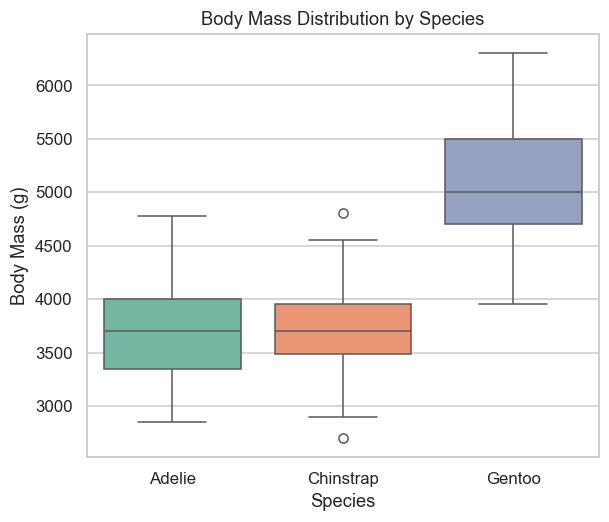

Penguins between 4400–4600 g:
species
Gentoo       5
Adelie       4
Chinstrap    3
Name: count, dtype: int64


In [9]:
stats = df.groupby('species')['body_mass_g'].agg(['mean', 'std', 'min', 'max'])
print(stats.round(1))

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='species', y='body_mass_g', 
            hue='species', palette='Set2', legend=False)
plt.title('Body Mass Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

near_4500 = df[(df['body_mass_g'] > 4400) & (df['body_mass_g'] < 4600)]
print('Penguins between 4400–4600 g:')
print(near_4500['species'].value_counts())

**Answer:**

Gentoo has the highest mean body mass (≈5076 g), yet the species distributions overlap substantially. A penguin weighing 4500 g could be a large Chinstrap or a small Gentoo, so body mass alone is not diagnostic. Comparing means is insufficient because a single summary statistic conceals the full spread and overlap visible in a box plot.


## Exercise 2: Scatter of Bill Length vs. Bill Depth Coloured by Species

Make a scatter plot of `bill_length_mm` (x) vs. `bill_depth_mm` (y), coloured by `species`. Describe what the colours reveal that a plain scatter hides.


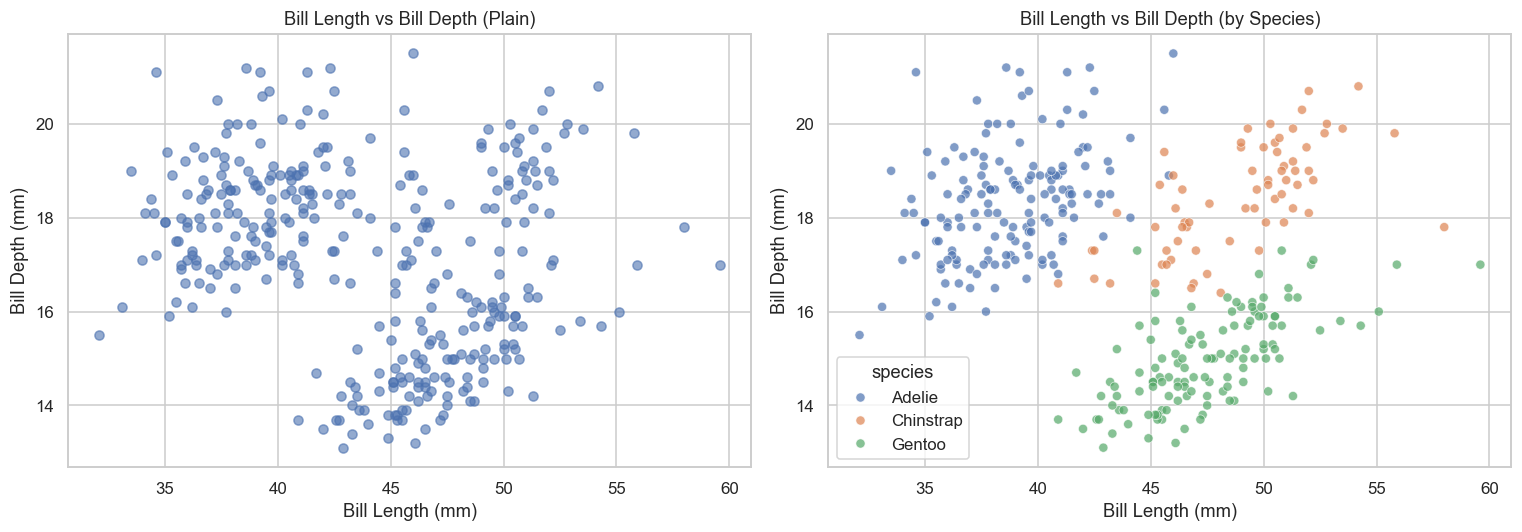

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['bill_length_mm'], df['bill_depth_mm'], alpha=0.6)
axes[0].set_title('Bill Length vs Bill Depth (Plain)')
axes[0].set_xlabel('Bill Length (mm)')
axes[0].set_ylabel('Bill Depth (mm)')

sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species', alpha=0.7, ax=axes[1])
axes[1].set_title('Bill Length vs Bill Depth (by Species)')
axes[1].set_xlabel('Bill Length (mm)')
axes[1].set_ylabel('Bill Depth (mm)')
plt.tight_layout()
plt.show()

**Answer:**

The **colours** reveal three **species**-separated **clusters** invisible in a plain **scatter plot**, which merely shows a single messy cloud with an overall **negative trend**. Adelie **penguins** occupy the lower-right (short **bill_length_mm**, medium **bill_depth_mm**), Chinstrap the upper-right (long bills, medium depth), and Gentoo the lower-left (long bills, shallow depth). Within each **species**, the two variables show a **positive correlation**, yet the pooled data show the opposite — a classic **Simpson's paradox**.


## Exercise 3: Cross-Tabulation — Species vs. Island

Build a cross-tab of `species` vs. `island` with row percentages (`normalize='index'`). Which island is home to only one species?


In [22]:
ct_counts = pd.crosstab(df['species'], df['island'])
ct_pct = pd.crosstab(df['species'], df['island'], normalize='index').round(3)

print('Counts:')
print(ct_counts)
print('\nRow percentages:')
print(ct_pct)


island_spp_count = ct_counts.astype(bool).sum(axis=0)
single_spp = island_spp_count[island_spp_count == 1]
print(f'\nIslands with only one species: {list(single_spp.index)}')

Counts:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0

Row percentages:
island     Biscoe  Dream  Torgersen
species                            
Adelie      0.289  0.368      0.342
Chinstrap   0.000  1.000      0.000
Gentoo      1.000  0.000      0.000

Islands with only one species: ['Torgersen']


**Answer:**

Torgersen and Dream each host only one species: Torgersen is exclusively Adelie (52, 100%), while Dream is exclusively Chinstrap (68, 100%). Biscoe alone contains multiple species—both Adelie (44) and Gentoo (124). Using row percentages in the cross-tabulation makes these single-species island allocations immediately visible.


## Exercise 4: Box Plot of Body Mass by Sex

Make a box plot of `body_mass_g` split by `sex`. Do males or females tend to be heavier?


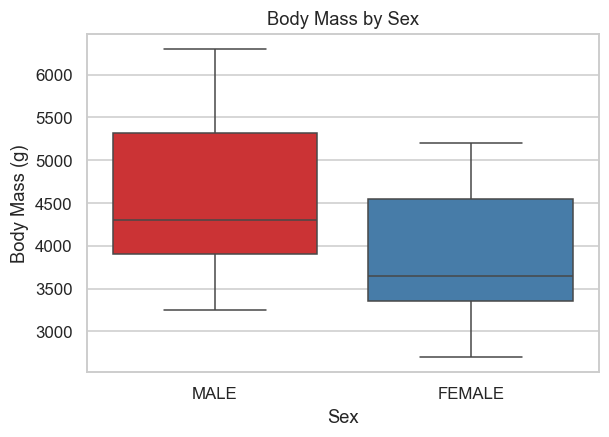

Body mass by sex:
          mean  median    std
sex                          
FEMALE  3862.3  3650.0  666.2
MALE    4545.7  4300.0  787.6


In [25]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='sex', y='body_mass_g', 
            hue='sex', palette='Set1', legend=False)
plt.title('Body Mass by Sex')
plt.xlabel('Sex')
plt.ylabel('Body Mass (g)')
plt.show()

sex_stats = df.groupby('sex')['body_mass_g'].agg(['mean', 'median', 'std'])
print('Body mass by sex:')
print(sex_stats.round(1))

**Answer:**

Males tend to be significantly heavier. Male penguins have a mean body mass of approximately 4546 g, compared to females at ~3862 g — a difference of nearly 700 g. 


## Exercise 5: Does One Number Tell the Truth?

From the correlation heatmap, name the *strongest* relationship and report its value. Then examine `bill_length_mm` vs. `bill_depth_mm` — the heatmap shows a weak negative correlation. Now make that scatter coloured by `species`. Does the single correlation value *honestly* summarise the relationship? Connect your answer to **Simpson's paradox**.


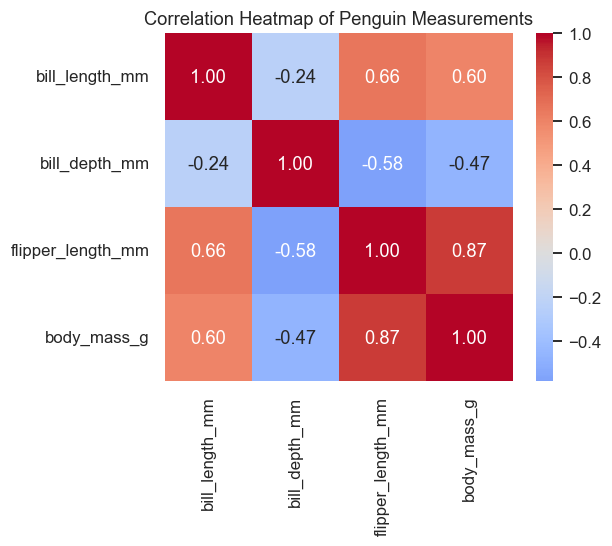

Strongest correlation: flipper_length_mm vs body_mass_g = 0.871

bill_length_mm vs bill_depth_mm (overall): -0.235

Within-species correlations (bill_length vs bill_depth):
  Adelie: 0.391
  Chinstrap: 0.654
  Gentoo: 0.643


In [28]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Penguin Measurements')
plt.tight_layout()
plt.show()

corr_unstacked = corr.unstack()
strongest = corr_unstacked[corr_unstacked < 1.0].sort_values(ascending=False)
print(f'Strongest correlation: {strongest.index[0][0]} vs {strongest.index[0][1]} = {strongest.iloc[0]:.3f}')
print(f'\nbill_length_mm vs bill_depth_mm (overall): {corr.loc["bill_length_mm", "bill_depth_mm"]:.3f}')

print('\nWithin-species correlations (bill_length vs bill_depth):')
for sp in df['species'].unique():
    subset = df[df['species'] == sp]
    r = subset['bill_length_mm'].corr(subset['bill_depth_mm'])
    print(f'  {sp}: {r:.3f}')

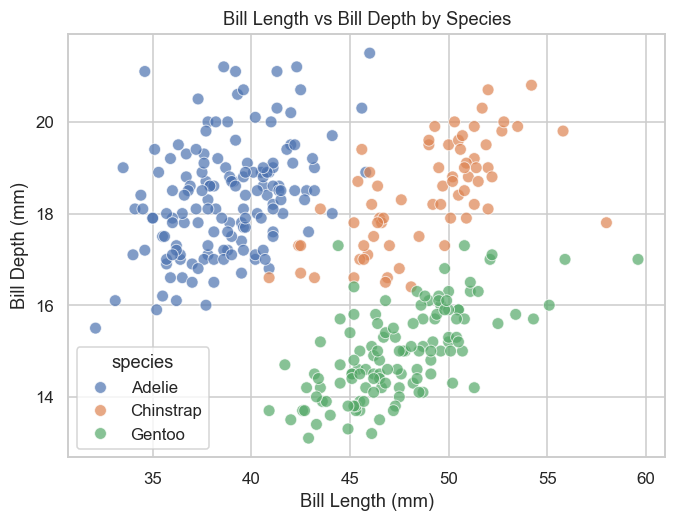

In [30]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species', alpha=0.7, s=60)
plt.title('Bill Length vs Bill Depth by Species')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.show()

**Answer:**

The strongest overall correlation links flipper_length_mm with body_mass_g (r ≈ 0.87).<p>
For bill_length_mm versus bill_depth_mm, the aggregated correlation across all species is weakly negative (≈ −0.24). Yet when stratified by species, every group shows a positive correlation (Adelie ≈ +0.39, Chinstrap ≈ +0.65, Gentoo ≈ +0.64).
The pooled value thus conceals the true pattern and even reverses its sign. This is Simpson's paradox: collapsing across a hidden grouping variable (species) produces an artificial negative trend absent within every individual group. Pooling populations with differing means and sizes yields a misleading overall slope that no single species exhibits.


## Exercise 6: Challenge — Make the Paradox Undeniable

Recreate the `sns.lmplot` from Section 6, then also fit a single trend line to the **pooled** data with `sns.regplot(..., scatter=False)`. Put both in one sentence: which way does the pooled line slope, and which way do the per-species lines slope?


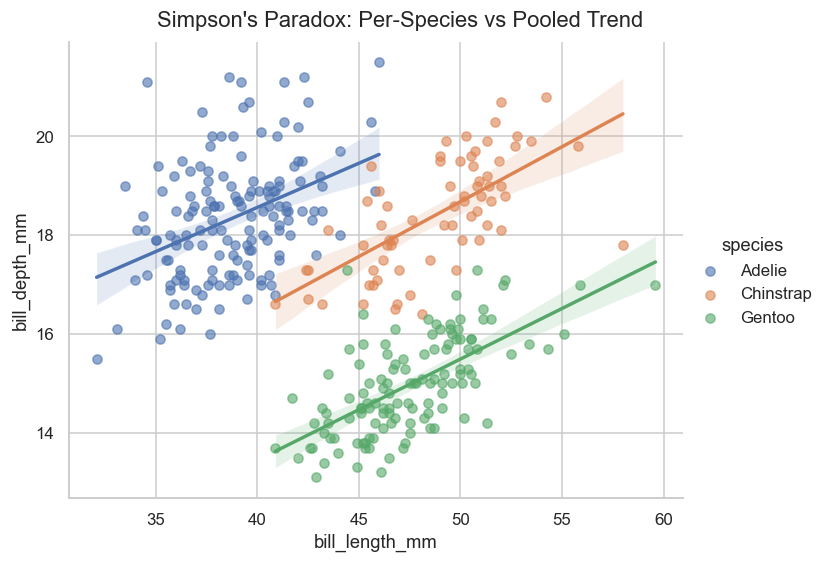

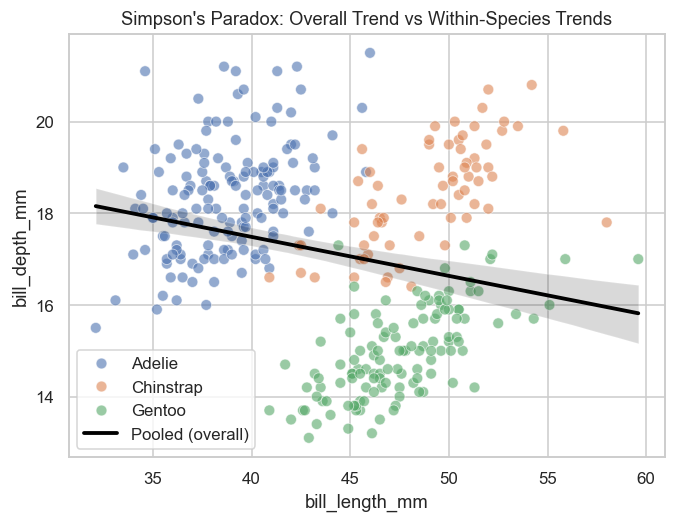

In [31]:
g = sns.lmplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species',
               height=5, aspect=1.3, scatter_kws={'alpha': 0.6})
g.fig.suptitle("Simpson's Paradox: Per-Species vs Pooled Trend", y=1.02)
plt.show()


plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species', alpha=0.6, s=50)
sns.regplot(data=df, x='bill_length_mm', y='bill_depth_mm', scatter=False, color='black', line_kws={'lw': 2.5}, label='Pooled (overall)')
plt.title("Simpson's Paradox: Overall Trend vs Within-Species Trends")
plt.legend()
plt.show()

**Answer:**

While all **per-species lines** slope **positive** (upward), the **pooled line** slopes **negative** (downward).